In [26]:
import importlib
import post_mcmc
import numpy as np
importlib.reload(post_mcmc)
from gala.coordinates import GreatCircleICRSFrame
import astropy.coordinates as coord
from astropy import units as u
import matplotlib.pyplot as plt
from post_mcmc import plot_form
import copy

In [27]:
min_dist = 18e3
fr = GreatCircleICRSFrame.from_pole_ra0(pole=coord.SkyCoord(ra=81.45*u.deg, dec=-6.346*u.deg), ra0=354.356*u.deg)

# def get_mem_path from directory, grabbing .fits file that includese 0.5%_mem in the name
def get_mem_path(directory):
    import os
    files = os.listdir(directory)
    for file in files:
        if ('0.5%_mem' in file or '50%_mem' in file) and file.endswith('.fits'):
            return os.path.join(directory, file)

mem_path = get_mem_path('/home/jupyter-nasserm/raid/nasserm/streamTutorialDr1/runs/Sylgr-I21_250913_spline_save')
stream_data, stream_run_directory = post_mcmc.load_stream_mems(mem_path)

In [28]:
stream_run_directory

'/home/jupyter-nasserm/raid/nasserm/streamTutorialDr1/runs/Sylgr-I21_250913_spline_save'

In [29]:
print('Loading desi_data...')
desi_data = post_mcmc.load_desi_data(fr=fr)
print('Desi data loaded')

Loading desi_data...
Length of DESI Data before Cuts: 15947824
Length of DESI Data after NaN cut: 11564120
Length of DESI data after RVS_WARN, RR_SPECTYPE, PRIMARY, VRAD_ERR, and FEH_ERR: 9429133
converting to phi1, phi2...
Desi data loaded


# Create stream class

In [30]:
importlib.reload(post_mcmc)
c19 = post_mcmc.StreamMembers(min_dist=18e3, stream_data=stream_data, desi_data = desi_data, stream_run_directory=stream_run_directory, fr=fr)

Using default isochrone path: ...iso_a13.5_z0.00010.dat
Loading desi_data...
Desi data loaded
getting BHB and RRL data...


Done


In [31]:
len(c19.stream_data['stream_prob'][c19.stream_data['stream_prob'] > 0.50])

121

## Multi Panel

No orbit results found, skipping orbit track plotting
/raid5b/users/nasserm/raid/nasserm/c19_2025/post_mcmc.py:1296: UserWarning: Rasterization of 'Spine' will be ignored
  def GaiaDECALS_cut(self, pad=[], GaiaDeCALS_path = '', upper_bound_feh=True, MaskList=['VGSR', 'FEH', 'PMRA', 'PMDEC', 'phi2'], save_fig=False, fig_path=None, addOrbit=False, useBox=False):



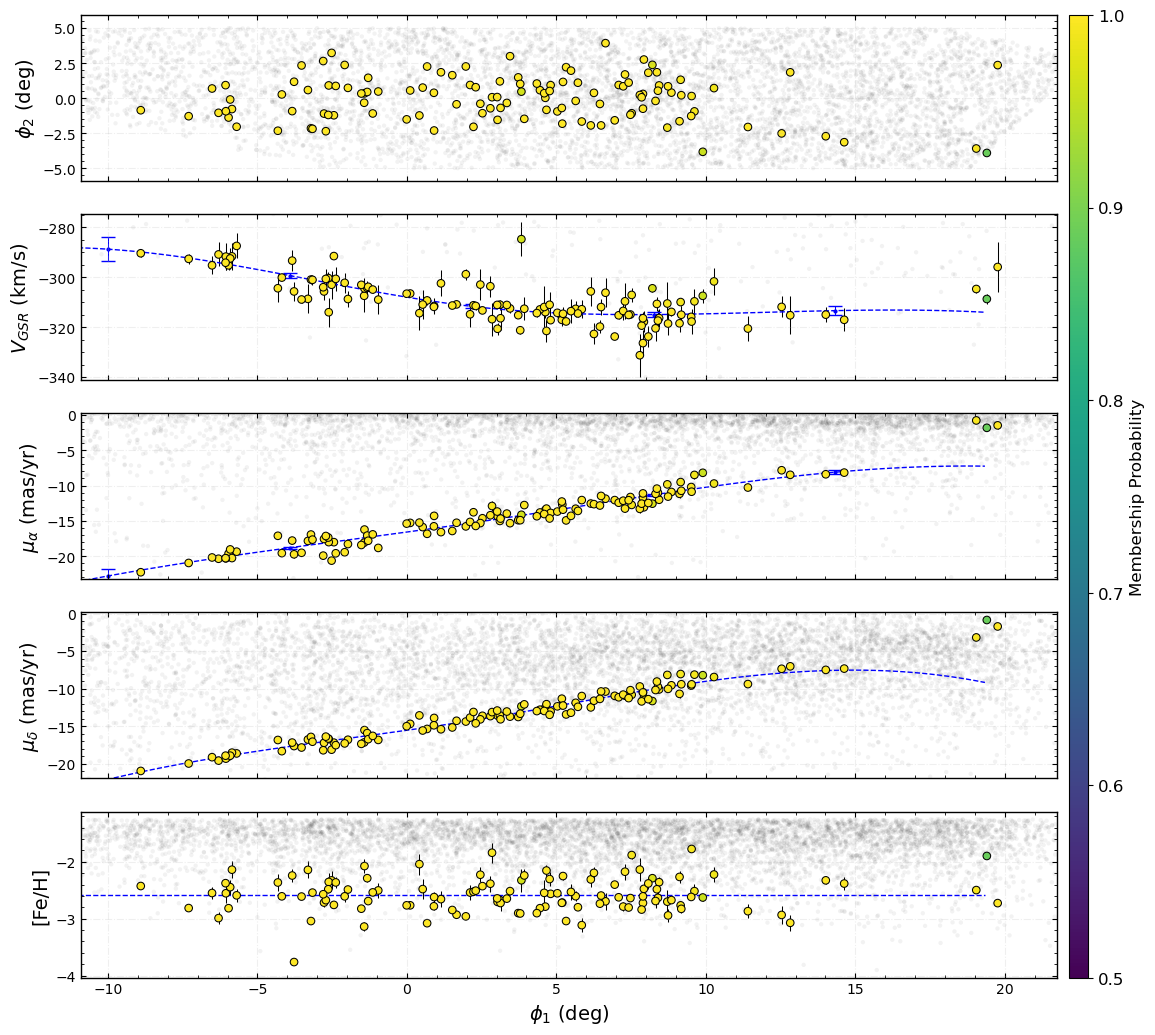

In [32]:
c19.vis_6_panel(addBackground=True, save_fig=False)

In [33]:
c19.print_meds()

FileNotFoundError: [Errno 2] No such file or directory: '/home/jupyter-nasserm/raid/nasserm/streamTutorialDr1/runs/Sylgr-I21_250913_spline_savemcmc_dict.npy'

# Box Cut

In [ ]:
pad = np.array([30, -2, 0.3, 0.3, 10]) # vgsr, feh, pmra, pmdec, phi2

Applying box cuts...
Not applying BHB cut
Box cuts applied. Access total masks using StreamMembers.<handler>.sel
Plotting box cuts...
Not applying BHB cut


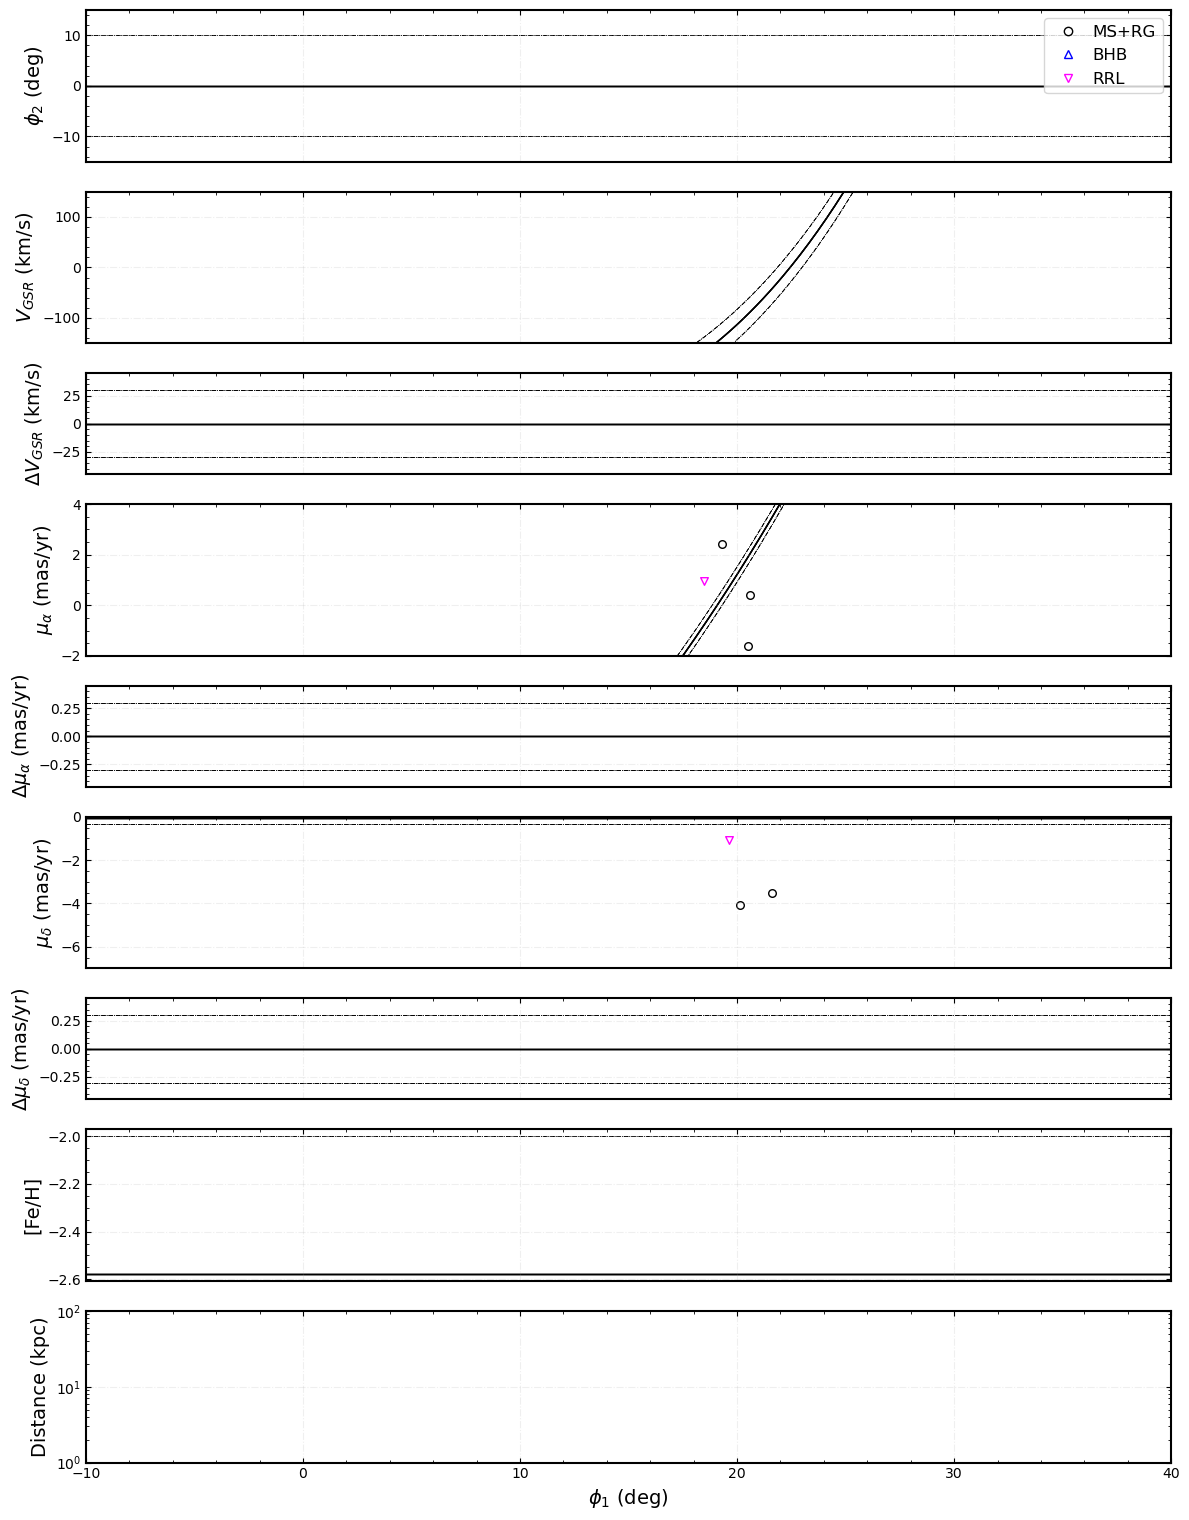

In [ ]:
c19.box_cut(pad=pad, with_plot=True, save_fig=True)

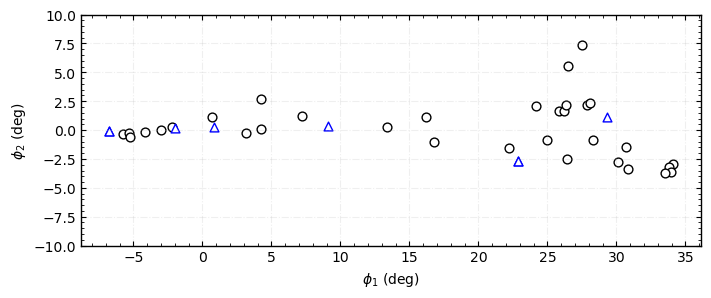

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 3))
ax.scatter(c19.ms_handler.data[c19.ms_handler.sel]['phi1'], c19.ms_handler.data[c19.ms_handler.sel]['phi2'], s=40, edgecolors='k', facecolors='white')
ax.scatter(c19.bhb_handler.data[c19.bhb_handler.sel]['phi1'], c19.bhb_handler.data[c19.bhb_handler.sel]['phi2'], s=40, edgecolors='b', facecolors='white', marker='^')
ax.set_ylabel(r'$\phi_2$ (deg)')
ax.set_xlabel(r'$\phi_1$ (deg)')
ax.set_ylim(-10, 10)
plot_form(ax)

# Orbit

This first cell is only needed if you're giving your own theta_init or orbit_kwargs

In [ ]:
import orbit_functions as ofuncs
#--------Select how many Gyrs you want to fit for-------------#
fw = np.linspace(0., 0.2, 4001) * u.Gyr
bw = np.linspace(0., -0.2, 4001) * u.Gyr
#------------------------------------------------------------#

#--------Set the distance of your progenitor-------------#
progenitor_dist = c19.min_dist/1000 # in kpc
#--------------------------------------------------------#

stream_data['RA'] = np.array(c19.stream_data['TARGET_RA'])
stream_data['DEC'] = np.array(c19.stream_data['TARGET_DEC'])

progenitor_ra = np.nanmean(stream_data['RA'])
distances = np.abs(stream_data['RA'] - progenitor_ra)

k = np.argsort(distances)
guess = {
    'DEC': np.nanmean(stream_data[k]['DEC'][:10]),
    'PMRA': np.nanmean(stream_data[k]['PMRA'][:10]),
    'PMDEC': np.nanmean(stream_data[k]['PMDEC'][:10]),
    'VRAD': np.nanmean(stream_data[k]['VRAD'][:10]),
    'DIST': progenitor_dist
}

guess['VGSR'] = ofuncs.vhel_to_vgsr(progenitor_ra*u.deg, guess['DEC']*u.deg, guess['VRAD']*u.km/u.s).value

# Prepare theta (initial guess array including log sigmas)
# You might need to adjust these initial log sigma values
lsig_dec_init = np.log10(0.1)  # Example: log10(0.1 deg)
lsig_pmra_init = np.log10(0.1) # Example: log10(0.1 mas/yr)
lsig_pmdec_init = np.log10(0.1)# Example: log10(0.1 mas/yr)
lsig_vrad_init = np.log10(1.0) # Example: log10(1 km/s)

theta_init = [
    guess['DEC'],
    guess['PMRA'],
    guess['PMDEC'],
    guess['VRAD'],
    guess['DIST'],
    lsig_dec_init,
    lsig_pmra_init,
    lsig_pmdec_init,
    lsig_vrad_init
]


# Corrected call to fit_orbit with theta_init and arguments in the right order
#result_o, orbit = ofuncs.fit_orbit(stream_data, fr, progenitor_ra, fw, bw, theta_init, use_position=True)


orbit parameters ['dec', 'pmra', 'pmdec', 'vrad', 'dist', 'lsig_dec', 'lsig_pmra', 'lsig_pmdec', 'lsig_vrad']
intital guess [-5.93490465546141, 0.3829196252683989, -4.604202193961402, -138.8217223347754, 18.0, -1.0, -1.0, -1.0, 0.0]
Optimization results_o:
Success: True
Status: 0
Message: Optimization terminated successfully.
Function Value: 553.7778033070165
Number of Iterations: 9
Number of Function Evaluations: 932
Progenitor
dec: -13.08 deg
pmra: 0.31 mas / yr
pmdec: -4.83 mas / yr
vrad: -116.64 km / s
dist: 16.48 kpc
lsig_dec: 2.06 deg
lsig_pmra: 1.16 mas / yr or 90.92 km / s
lsig_pmdec: 0.15 mas / yr or 11.35 km / s
lsig_vrad: 10.99 km / s
Pericenter: 16.47 kpc 
Apocenter: 22.07 kpc
Orbital period: 0.38


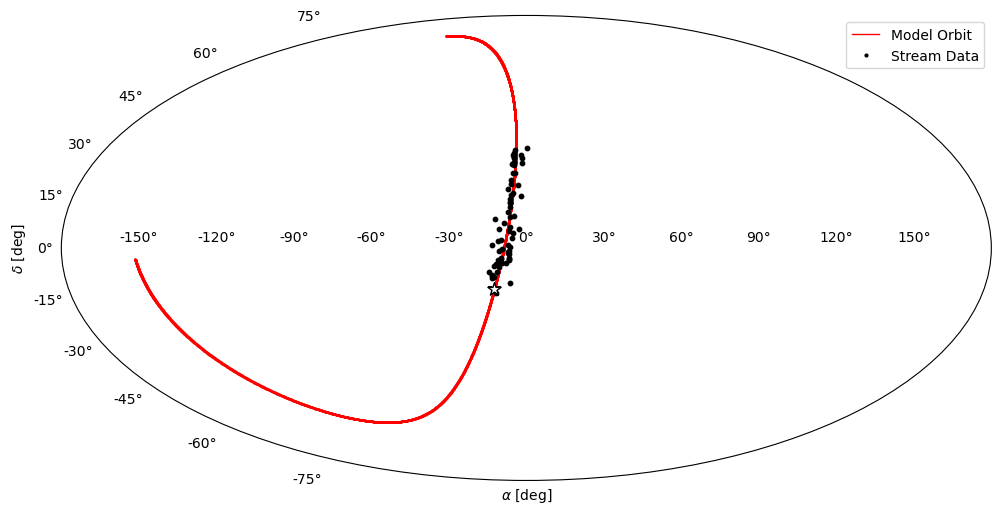

In [ ]:
progenitor_ra = np.nanmean(c19.stream_data['RA'])

results_o, orbit, fig, ax = c19.do_orbit(progenitor_RA=progenitor_ra, with_plot=True)

/raid5b/users/nasserm/raid/nasserm/c19_2025/post_mcmc.py:1227: UserWarning: Rasterization of 'Spine' will be ignored
  artist.set_rasterized(True)



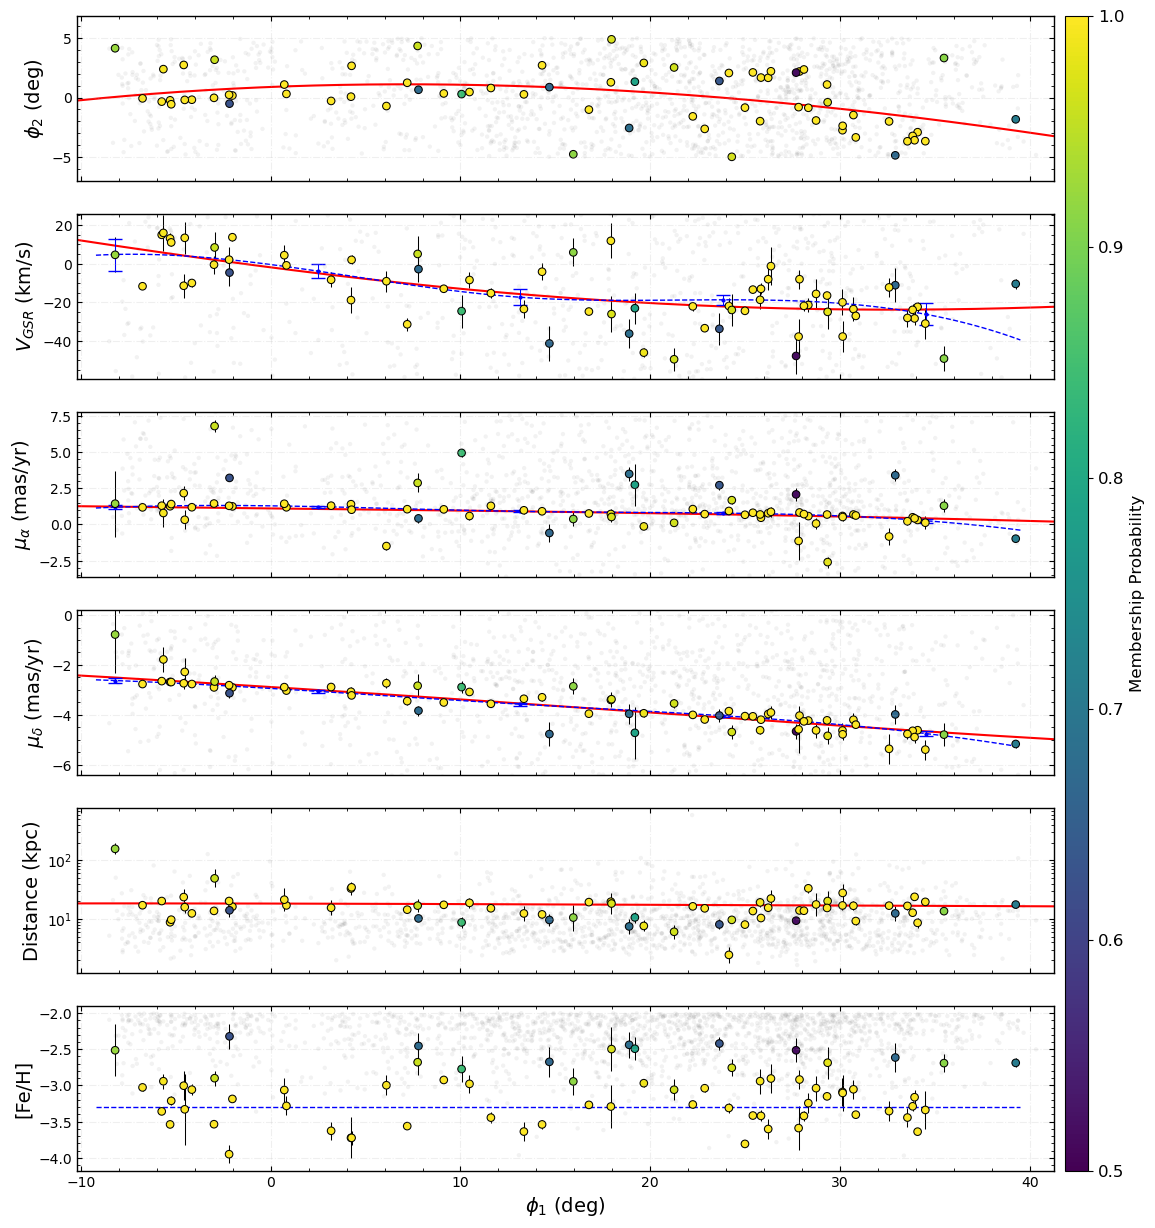

In [ ]:
c19.vis_6_panel(addBackground=True, save_fig=True)

# vdisp

## vdisp gmm

In [ ]:
## get 5 spline for vdisp and memprob from other run
importlib.reload(post_mcmc)
mem_path2 = get_mem_path('/home/jupyter-nassermoha/raid_nassermoha/data/runs/C-19-I21_250717_bugfix')
stream_data2, stream_run_directory2 = post_mcmc.load_stream_mems(mem_path2)
c19_5 = post_mcmc.StreamMembers(min_dist=18e3, stream_data=stream_data2, stream_run_directory=stream_run_directory2, fr=fr)

Using default isochrone path: ...iso_a13.5_z0.00010.dat
Loading desi_data...
No desi_data provided, will not use DESI data
Skipping BHB and RRL Data
Done


In [ ]:
pdic = c19_5.return_spline_track(0)
lsig = c19_5.return_spline_track(2)

running segment -10 to 8 deg
running segment 8 to 23 deg
running segment 23 to 36 deg
Segment -10 to 8 deg:
  mean RV: -0.06 (+2.43/-2.52)
  σ_v:     10.20 (+2.13/-1.75)
Segment 8 to 23 deg:
  mean RV: -1.90 (+5.03/-4.83)
  σ_v:     16.62 (+4.52/-3.18)
Segment 23 to 36 deg:
  mean RV: -0.26 (+1.30/-1.29)
  σ_v:     5.01 (+1.56/-1.17)
 
OVERALL
  mean RV: -0.84 (+1.35/-1.43)
  σ_v:     9.97 (+1.26/-1.07)
/tmp/ipykernel_2684820/610166623.py:19: UserWarning: Rasterization of 'Spine' will be ignored
  artist.set_rasterized(True)



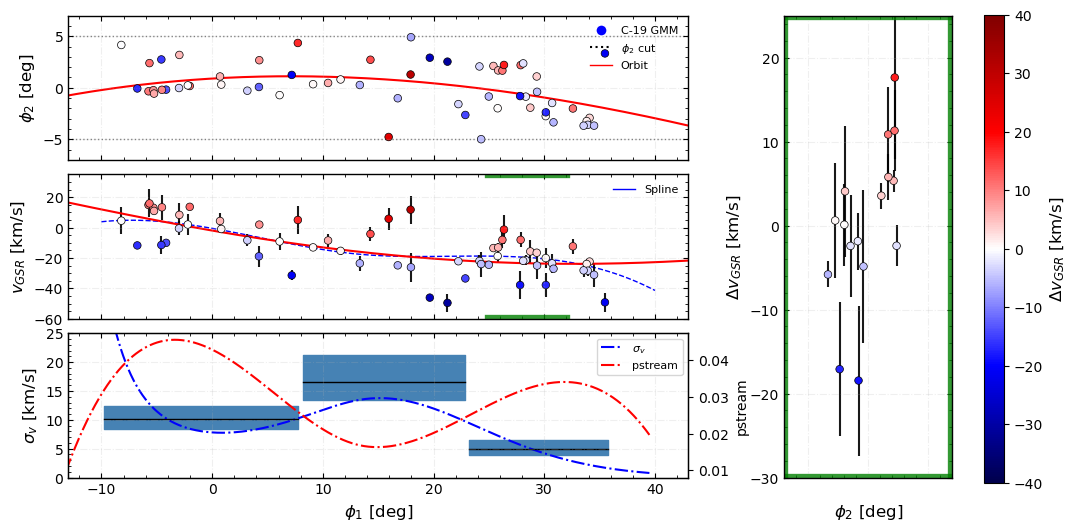

In [ ]:
segments = [(-10, 8), (8, 23),(23, 36)] # the bounds of the boxes for calculating the velocity dispersion
#c19.segment_vdisp(segments, green_min = 25, green_max=32, useBox=False, externalSpline=True, prob_cutoff=0.9)
fig, ax = c19.segment_vdisp(segments, green_min = 25, green_max=32, useBox=False, externalSpline=True, prob_cutoff=0.9)
x_arr = np.linspace(-10, 40, 100)

# c19_5.add_spline_track(ax[2], med_ind=2, label=r'MCMC $\sigma_v$', color='blue')

ax_twin = ax[2].twinx()
ax_twin.plot(pdic['phi1'], np.log10(pdic['spline']), color='red', ls='-.', label='pstream', zorder=0)
ax[2].plot(lsig['phi1'], (lsig['spline']), color='blue', ls='-.', label=r'$\sigma_v$', zorder=0)
ax_twin.set_ylabel(r'pstream', fontsize=10)

ax[2].plot([],[], color='red', ls='-.', label='pstream')
ax[2].legend(loc='upper right', fontsize=8)


for ax in plt.gcf().get_axes():
    for artist in ax.get_children():
        artist.set_rasterized(True)
fig_path = 'figures_draft/postmcmc_vdispgmm_wsigma.pdf'
plt.savefig(fig_path, bbox_inches='tight', dpi=600)


## 5 spline

running segment -10 to 8 deg
running segment 8 to 23 deg
running segment 23 to 36 deg
Segment -10 to 8 deg:
  mean RV: -1.40 (+2.76/-2.71)
  σ_v:     10.62 (+2.46/-1.87)
Segment 8 to 23 deg:
  mean RV: 2.60 (+4.18/-3.94)
  σ_v:     11.83 (+4.23/-2.95)
Segment 23 to 36 deg:
  mean RV: 0.42 (+1.33/-1.23)
  σ_v:     4.37 (+1.34/-0.96)
 
OVERALL
  mean RV: 0.10 (+1.34/-1.34)
  σ_v:     8.50 (+1.16/-1.00)
No orbit has been run yet, plots will not include orbit track
/tmp/ipykernel_2684820/3340543329.py:19: UserWarning: Rasterization of 'Spine' will be ignored
  artist.set_rasterized(True)



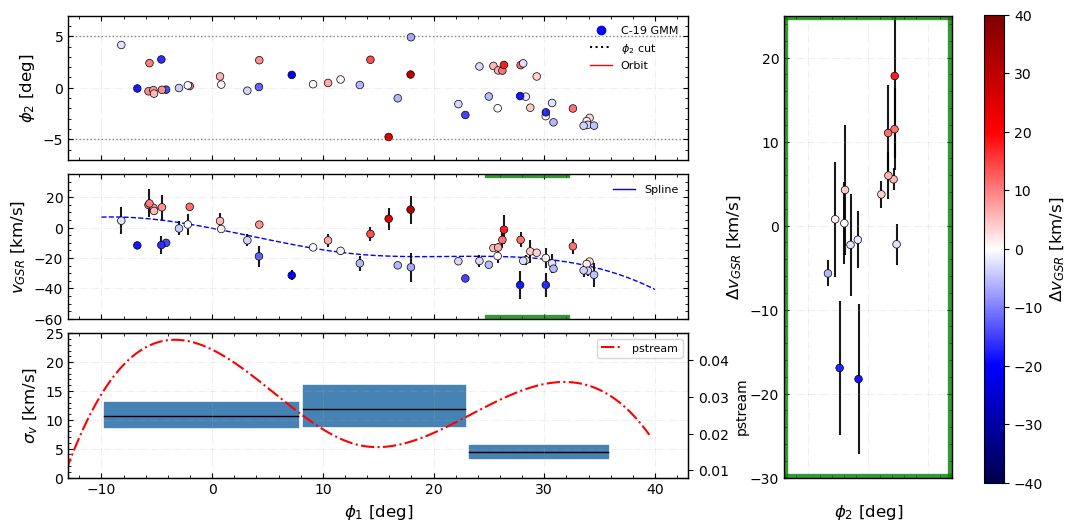

In [ ]:
segments = [(-10, 8), (8, 23),(23, 36)] # the bounds of the boxes for calculating the velocity dispersion
#c19.segment_vdisp(segments, green_min = 25, green_max=32, useBox=False, externalSpline=True, prob_cutoff=0.9)
fig, ax = c19_5.segment_vdisp(segments, green_min = 25, green_max=32, useBox=False, externalSpline=True, prob_cutoff=0.9)
x_arr = np.linspace(-10, 40, 100)

# c19_5.add_spline_track(ax[2], med_ind=2, label=r'MCMC $\sigma_v$', color='blue')

ax_twin = ax[2].twinx()
ax_twin.plot(pdic['phi1'], np.log10(pdic['spline']), color='red', ls='-.', label='pstream', zorder=0)
#ax[2].plot(lsig['phi1'], (lsig['spline']), color='blue', ls='-.', label=r'$\sigma_v$', zorder=0)
ax_twin.set_ylabel(r'pstream', fontsize=10)

ax[2].plot([],[], color='red', ls='-.', label='pstream')
ax[2].legend(loc='upper right', fontsize=8)


for ax in plt.gcf().get_axes():
    for artist in ax.get_children():
        artist.set_rasterized(True)
fig_path = 'figures_draft/postmcmc_vdispgmm_5.png'
plt.savefig(fig_path, bbox_inches='tight', dpi=600)


# Vdisp stars investigation

Removing the 4 stars far from track in center of stream

In [ ]:
len(c19.stream_data)

70

In [ ]:
sel_vdisp =  (c19.stream_data['phi1'] < 20) & (c19.stream_data['VGSR'] >-10) & (c19.stream_data['phi1'] > 12.5)
sel_vdisp2 = (c19.stream_data['phi1'] >17.5) & (c19.stream_data['phi1'] < 20)
cut_mask = ~(sel_vdisp | sel_vdisp2)
cut_mask2 = (sel_vdisp | sel_vdisp2)
stream_data_ = c19.stream_data[cut_mask].copy() 
stream_data_small = c19.stream_data[cut_mask2].copy()
print(len(stream_data_))

63


In [ ]:
c19_trim = copy.copy(c19)
c19_trim.stream_data = stream_data_

running segment -10 to 8 deg
running segment 8 to 23 deg
running segment 23 to 36 deg
Segment -10 to 8 deg:
  mean RV: 0.00 (+2.60/-2.52)
  σ_v:     10.10 (+2.14/-1.66)
Segment 8 to 23 deg:
  mean RV: -6.07 (+3.66/-3.60)
  σ_v:     9.69 (+4.13/-2.65)
Segment 23 to 36 deg:
  mean RV: -0.28 (+1.29/-1.38)
  σ_v:     5.09 (+1.55/-1.22)
 
OVERALL
  mean RV: -1.29 (+1.32/-1.25)
  σ_v:     8.44 (+1.11/-0.98)


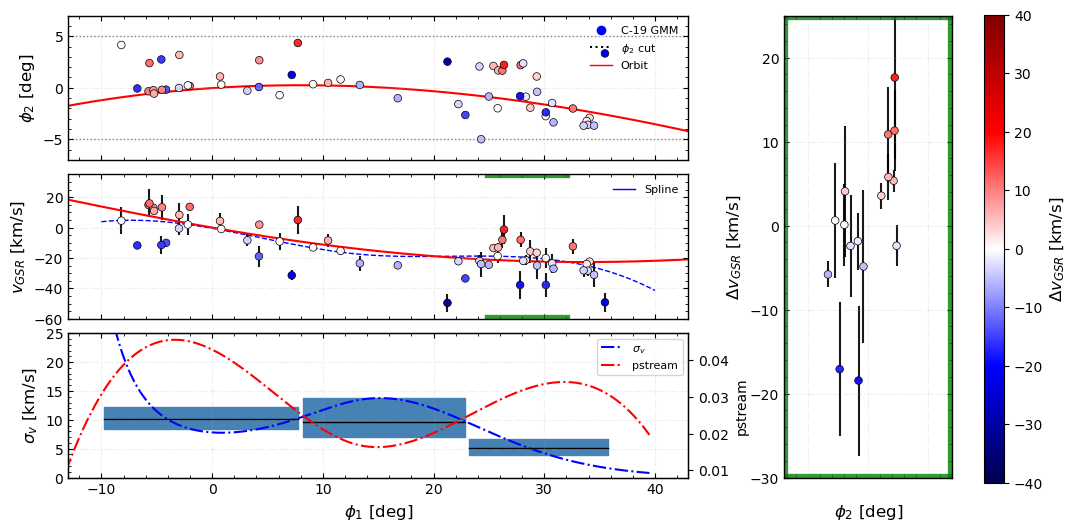

In [ ]:

segments = [(-10, 8), (8, 23),(23, 36)] # the bounds of the boxes for calculating the velocity dispersion
#c19.segment_vdisp(segments, green_min = 25, green_max=32, useBox=False, externalSpline=True, prob_cutoff=0.9)
fig, ax = c19_trim.segment_vdisp(segments, green_min = 25, green_max=32, useBox=False, externalSpline=True, prob_cutoff=0.9)
x_arr = np.linspace(-10, 40, 100)

# c19_5.add_spline_track(ax[2], med_ind=2, label=r'MCMC $\sigma_v$', color='blue')

#ax[1].scatter(stream_data_small['phi1'], stream_data_small['VGSR'], c='k', alpha=0.5, s=10)
ax_twin = ax[2].twinx()
ax_twin.plot(pdic['phi1'], np.log10(pdic['spline']), color='red', ls='-.', label='pstream', zorder=0)
ax[2].plot(lsig['phi1'], (lsig['spline']), color='blue', ls='-.', label=r'$\sigma_v$', zorder=0)
ax_twin.set_ylabel(r'pstream', fontsize=10)

ax[2].plot([],[], color='red', ls='-.', label='pstream')
ax[2].legend(loc='upper right', fontsize=8)

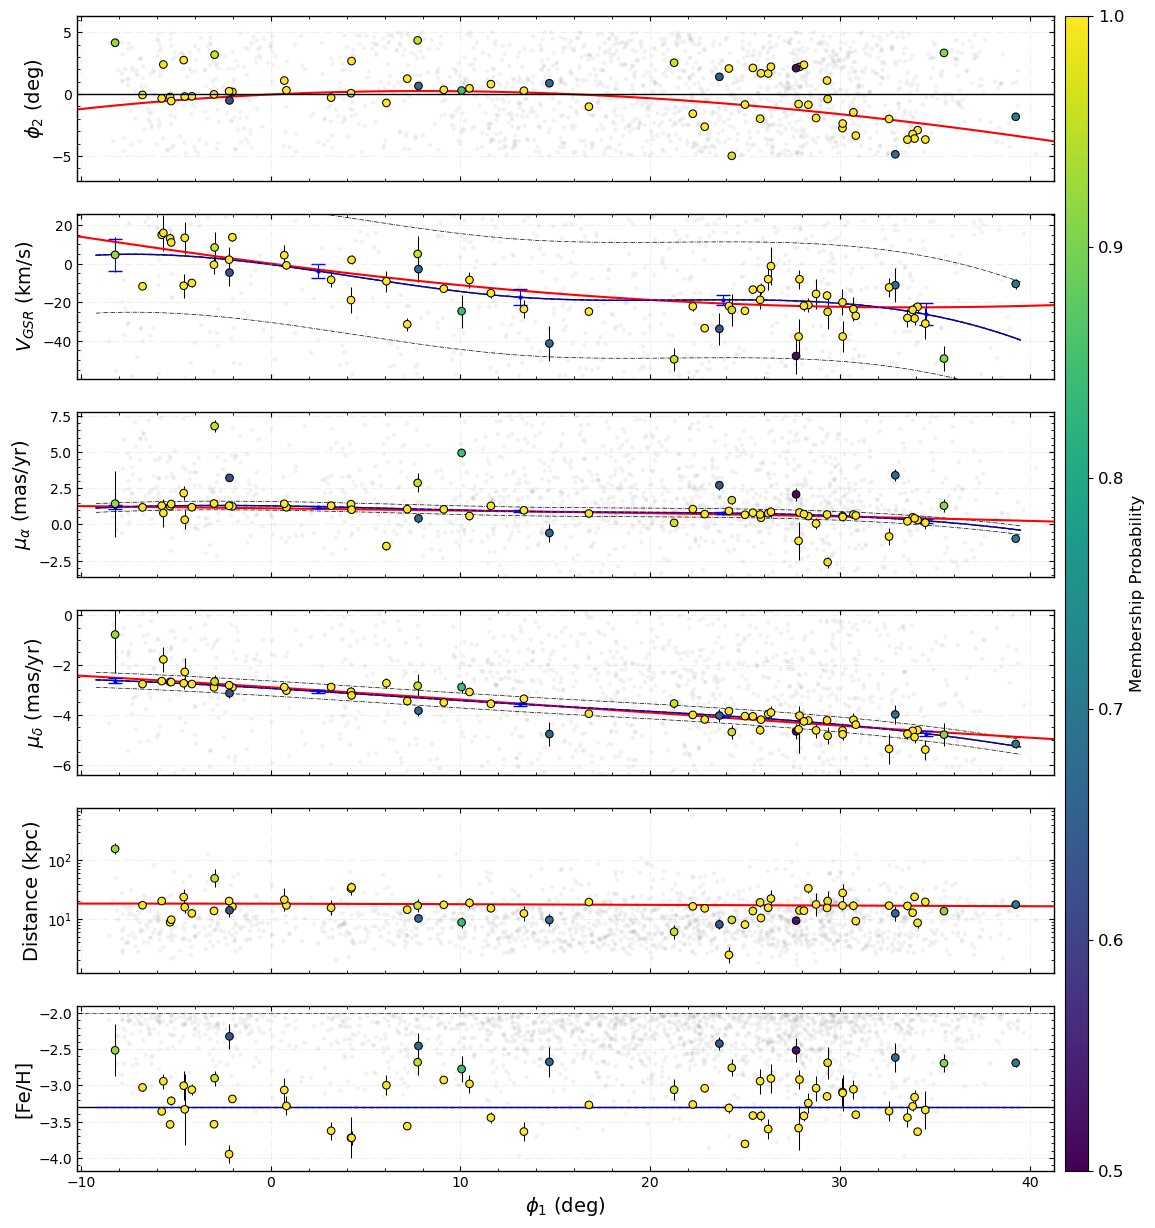

In [ ]:
c19_trim.vis_6_panel(addBackground=True, save_fig=True, pad=pad)

In [ ]:
print(stream_data_small['phi1'])

       phi1       
------------------
19.662031584346927
18.889162102054883
17.925431284753266
17.958163719117277
14.299452608402092
15.945023971810352
19.190149500732048


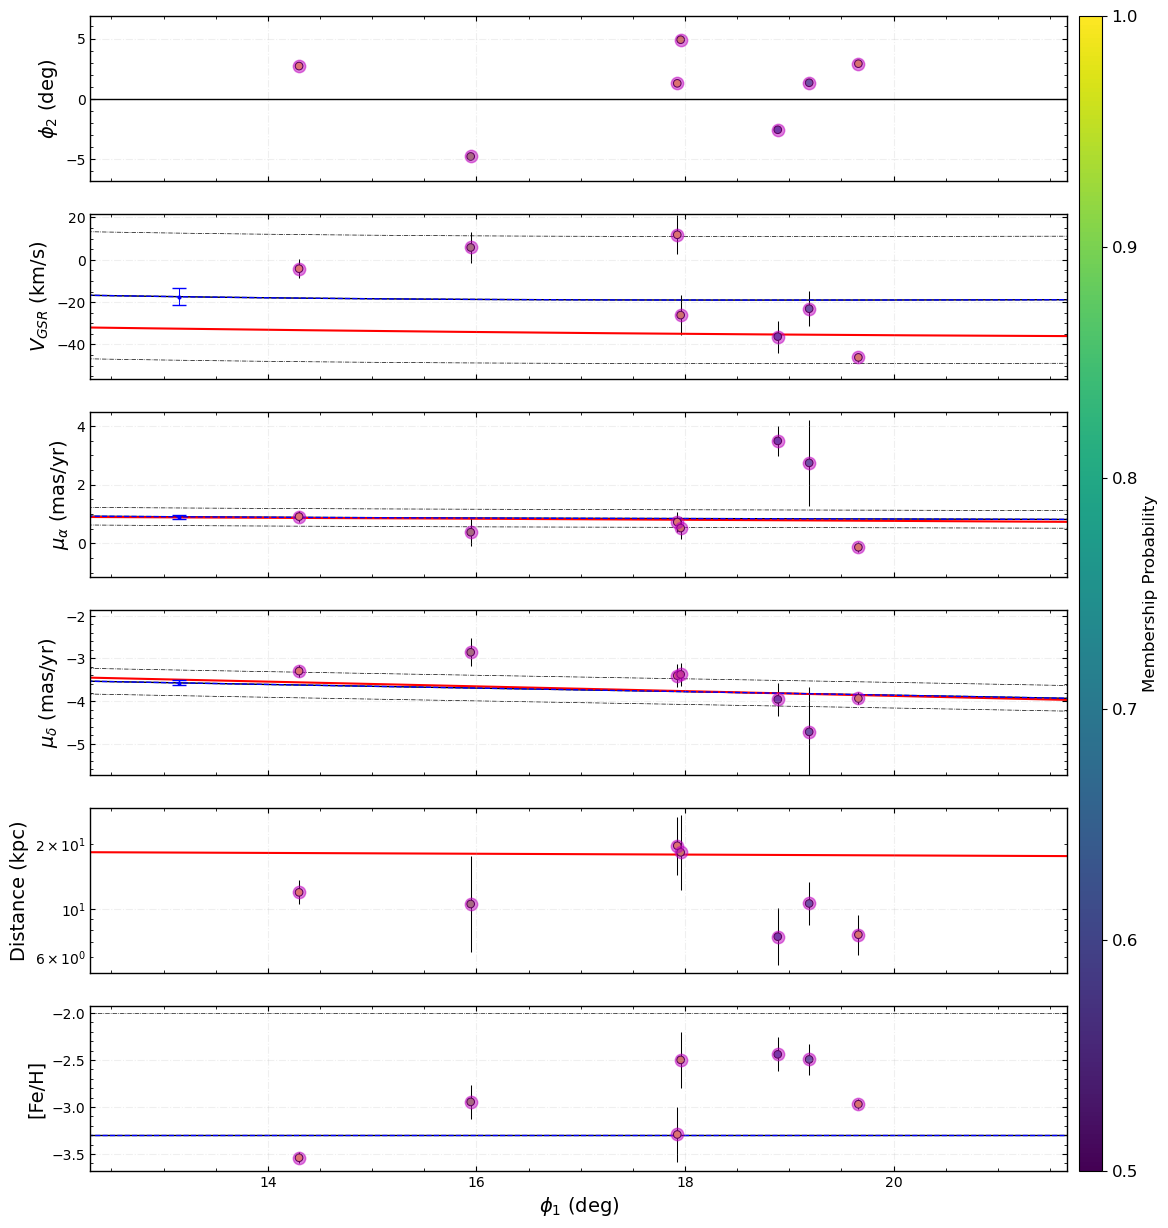

In [ ]:
c19_trim_small = copy.deepcopy(c19)
c19_trim_small.stream_data = stream_data_small
c19_trim_small.vis_6_panel(addBackground=False, save_fig=False, pad=pad, highlight=stream_data_small)

In [ ]:
print(stream_data_small['phi1'])

       phi1       
------------------
19.662031584346927
18.889162102054883
17.925431284753266
17.958163719117277
14.299452608402092
15.945023971810352
19.190149500732048


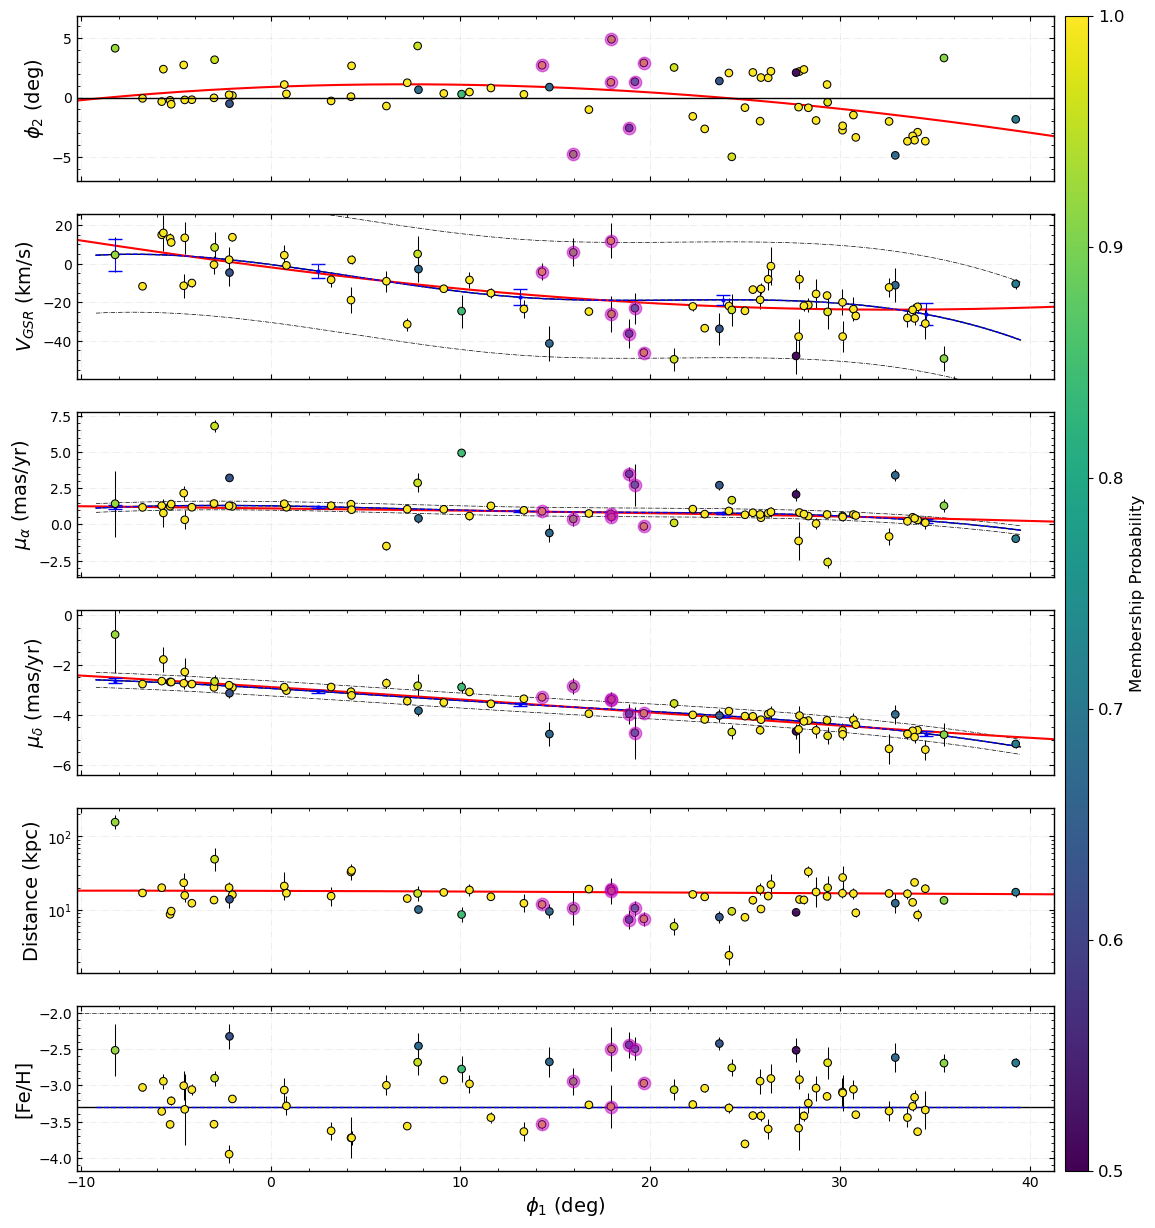

In [ ]:
pad = np.array([30, -2, 0.3, 0.3, 10]) # vgsr, feh, pmra, pmdec, phi2
c19.vis_6_panel(addBackground=False, save_fig=False, pad=pad, highlight=stream_data_small)

Applying box cuts...
Not applying BHB cut
/raid5b/users/nasserm/raid/nasserm/c19_2025/post_mcmc.py:887: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.box_data = pd.concat([self.ms_handler.data[self.ms_handler.sel], self.bhb_handler.data[self.bhb_handler.sel], self.rrl_handler.data[self.rrl_handler.sel]], ignore_index=True)

Box cuts applied. Access total masks using StreamMembers.<handler>.sel
Plotting box cuts...
Not applying BHB cut


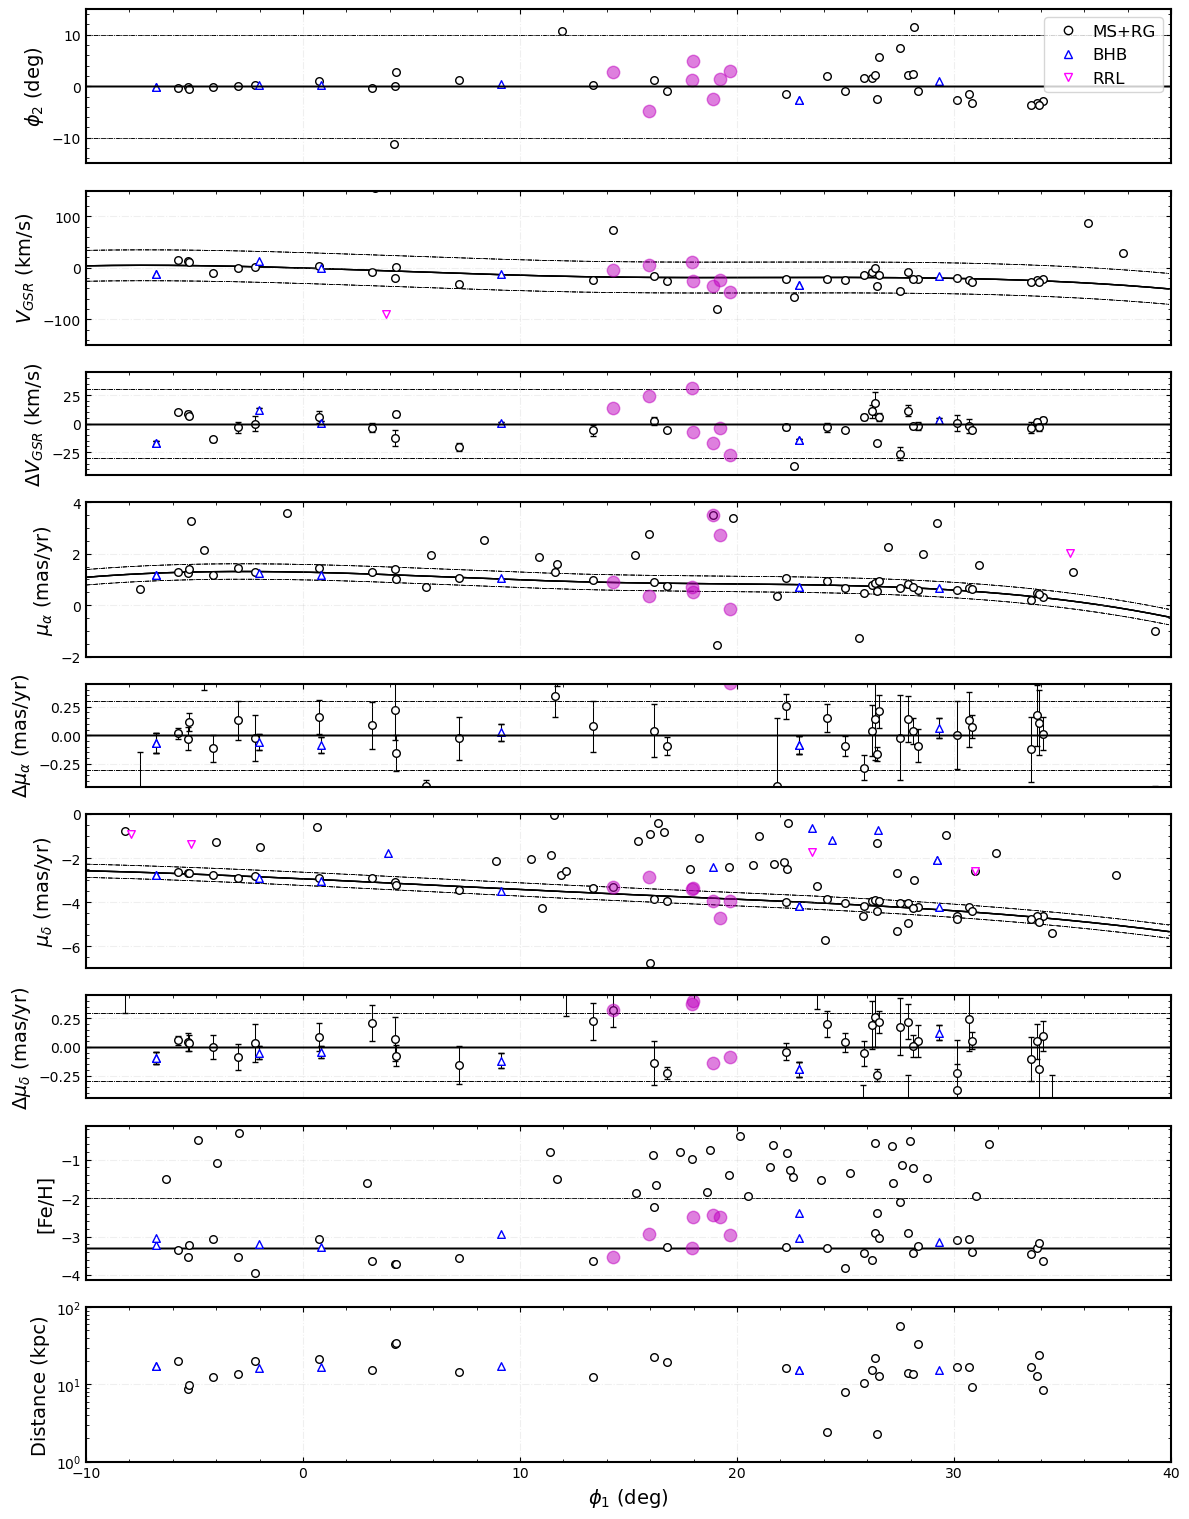

In [ ]:
pad = np.array([30, -2, 0.3, 0.3, 10]) 
c19.box_cut(pad=pad, with_plot=True, save_fig=False, highlight=stream_data_small)

## vdisp box_cut

running segment -10 to 8 deg
running segment 8 to 23 deg
running segment 23 to 36 deg
Segment -10 to 8 deg:
  mean RV: -2.29 (+3.13/-2.98)
  σ_v:     11.35 (+2.74/-1.95)
Segment 8 to 23 deg:
  mean RV: -6.26 (+2.77/-2.71)
  σ_v:     6.67 (+2.76/-1.71)
Segment 23 to 36 deg:
  mean RV: -1.09 (+1.99/-2.01)
  σ_v:     7.68 (+1.91/-1.49)
 
OVERALL
  mean RV: -2.49 (+1.58/-1.45)
  σ_v:     9.08 (+1.23/-1.10)


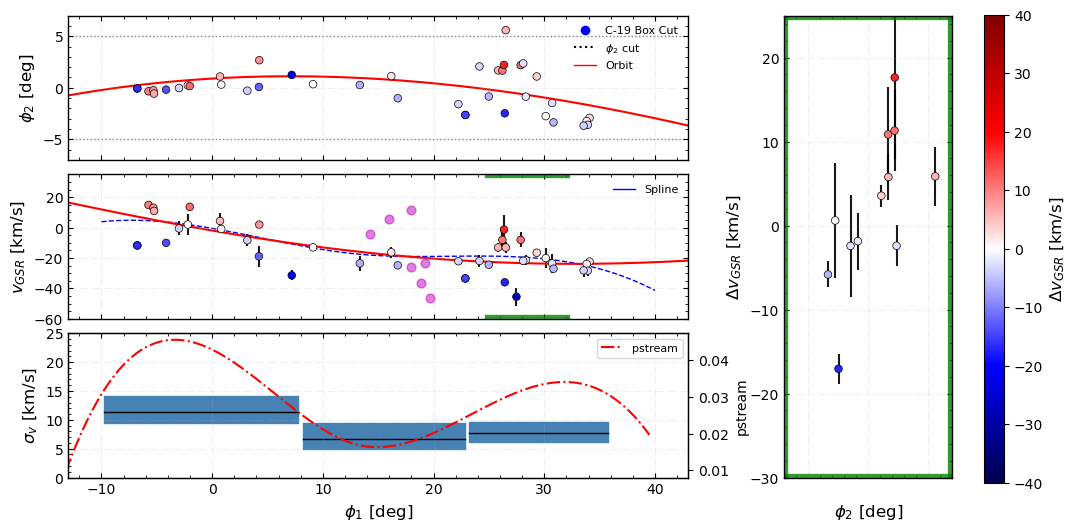

In [ ]:
segments = [(-10, 8), (8, 23),(23, 36)] # the bounds of the boxes for calculating the velocity dispersion
#c19.segment_vdisp(segments, green_min = 25, green_max=32, useBox=False, externalSpline=True, prob_cutoff=0.9)
fig, ax = c19.segment_vdisp(segments, green_min = 25, green_max=32, useBox=True, externalSpline=True, prob_cutoff=0.5)
x_arr = np.linspace(-10, 40, 100)

# c19_5.add_spline_track(ax[2], med_ind=2, label=r'MCMC $\sigma_v$', color='blue')

ax_twin = ax[2].twinx()
ax_twin.plot(pdic['phi1'], np.log10(pdic['spline']), color='red', ls='-.', label='pstream', zorder=0)
ax_twin.set_ylabel(r'pstream', fontsize=10)

ax[2].plot([],[], color='red', ls='-.', label='pstream')
ax[2].legend(loc='upper right', fontsize=8)
ax[1].scatter(stream_data_small['phi1'], stream_data_small['VGSR'], s=40, c='m', alpha=0.5)

# for ax in plt.gcf().get_axes():
#     for artist in ax.get_children():
#         artist.set_rasterized(True)
# fig_path = 'figures_draft/postmcmc_vdispbox.png'
# plt.savefig(fig_path, bbox_inches='tight', dpi=600)

# Gaia + DeCALS

Duplicates: 67717
Duplicates remaining: 7510
/raid5b/users/nasserm/raid/nasserm/c19_2025/post_mcmc.py:403: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data['delta_mag'] = np.abs(self.data['rmag']-self.data['phot_g_mean_mag'])

/raid5b/users/nasserm/raid/nasserm/c19_2025/post_mcmc.py:404: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data.sort_values('delta_mag', inplace=True)

Duplicates remaining: 0
Converting to phi1, phi2...
showing GaiaDeCALS data in stream frame...
Applied cuts: [ 0.3  0.3 10. ] for panels: ['pmra', 'pmdec', 'phi2'], with a paral

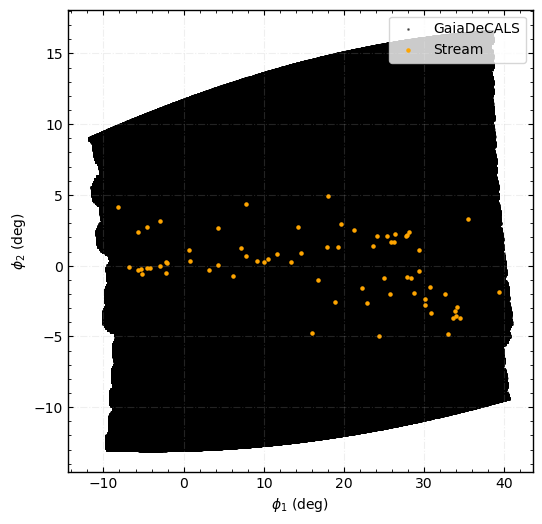

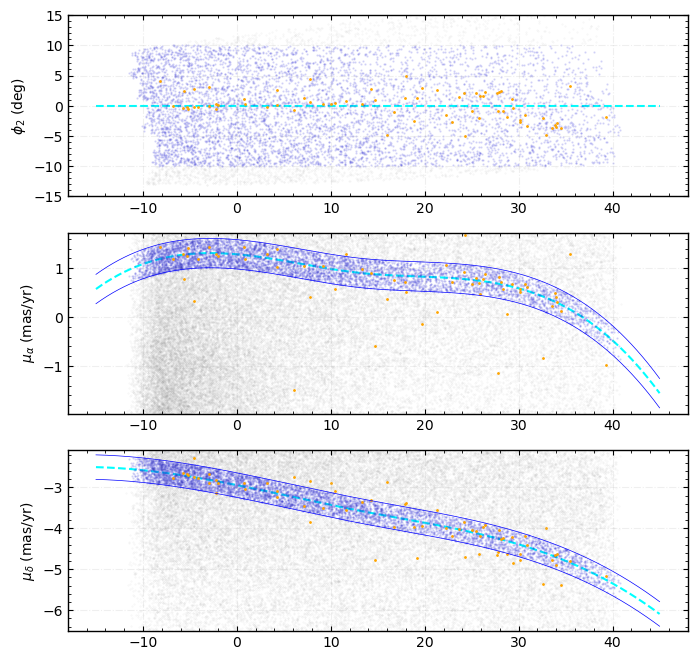

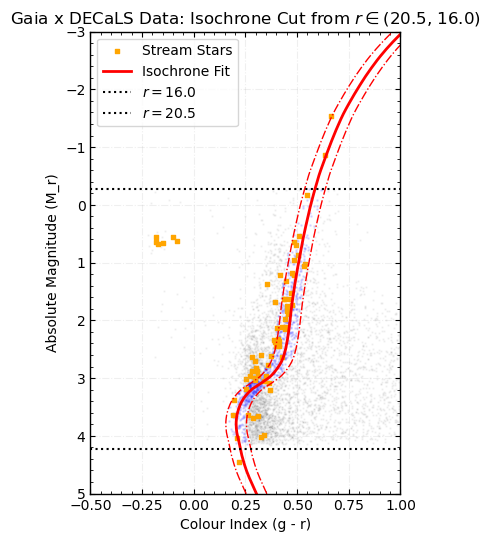

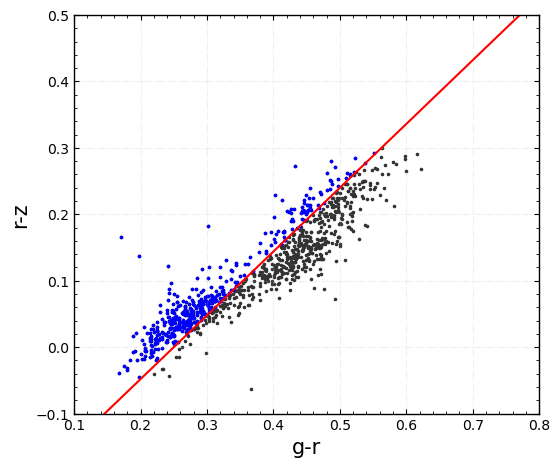

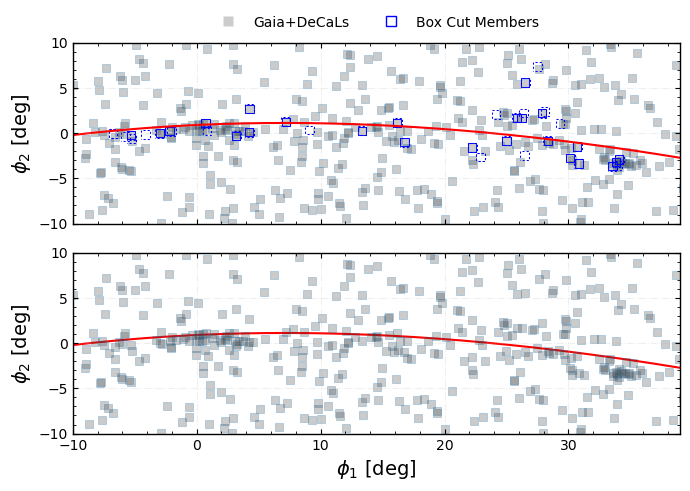

In [ ]:
c19.GaiaDECALS_cut(GaiaDeCALS_path='/home/jupyter-nassermoha/raid_nassermoha/data/C-19_gaia_x_decals_nasser_phi2_10.fits', addOrbit=True, useBox=True)

# Visualize Isochrone

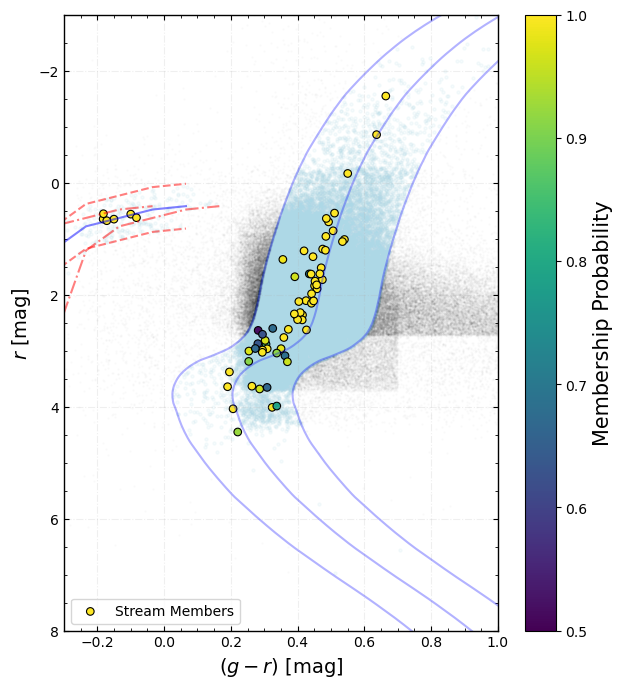

In [ ]:
c19.vis_isochrone()

# Stream On-Sky

In [ ]:
desi_ra_rad = np.radians(post_mcmc.zero_360_to_180(desi_data['TARGET_RA']))
desi_dec_rad = np.radians(desi_data['TARGET_DEC'])

stream_ra_rad = np.radians(post_mcmc.zero_360_to_180(stream_data['TARGET_RA']))
stream_dec_rad = np.radians(stream_data['TARGET_DEC'])


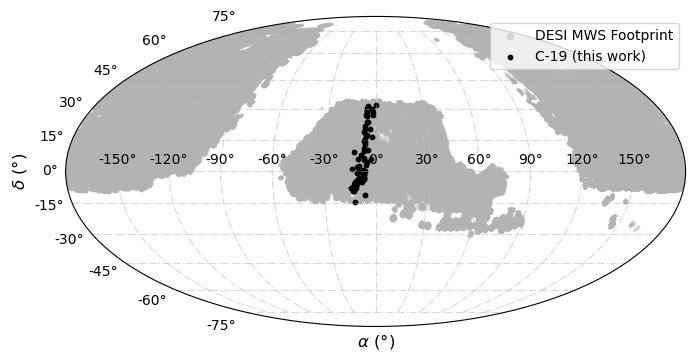

In [ ]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="mollweide")

ax.scatter(desi_ra_rad, desi_dec_rad, s=0.1, c='0.7', alpha=0.01, zorder=0)
ax.scatter([], [], s=20, c='0.7', alpha=0.4, label='DESI MWS Footprint', zorder=0)
ax.scatter(stream_ra_rad, stream_dec_rad, s=10, c='k', zorder=1, label='C-19 (this work)')

ax.set_xlabel(r"$\alpha$ (°)", fontsize=12)
ax.set_ylabel(r"$\delta$ (°)", fontsize=12)

# Optional: customize RA tick labels to show degrees from 360° to 0°
#tick_labels_deg = np.array([150, 120, 90, 60, 30, 0, 330, 300, 270, 240, 210])
#tick_labels_rad = np.radians(tick_labels_deg - 180)  # Center 0° RA in middle
#ax.set_xticks(tick_labels_rad)
#ax.set_xticklabels([f"{l}°" for l in tick_labels_deg])
ax.grid(True, zorder=0, alpha=0.5, ls='-.')
ax.legend(loc='upper right', fontsize=10)

for ax in plt.gcf().get_axes():
    for artist in ax.get_children():
        artist.set_rasterized(True)

fig_path = 'figures_draft/allsky.pdf'
#plt.savefig(fig_path, bbox_inches='tight', dpi=600)
plt.show()
